In [2]:
import pandas as pd

# Load the dataset
df = pd.read_excel('Delinquency_prediction_dataset.xlsx')

# 1. Audit for missing values (Gaps)
print("--- Missing Values Report ---")
print(df.isnull().sum())

# 2. Statistical overview to find anomalies
print("\n--- Data Summary ---")
print(df.describe())

# 3. Preview the first 5 rows
df.head()

--- Missing Values Report ---
Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64

--- Data Summary ---
              Age         Income  Credit_Score  Credit_Utilization  \
count  500.000000     461.000000    498.000000          500.000000   
mean    46.266000  108379.893709    577.716867            0.491446   
std     16.187629   53662.723741    168.881211            0.197103   
min     18.000000   15404.000000    301.000000            0.050000   
25%     33.000000   62295.000000    418.250000            0.356486   
50

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [3]:
# 1. Filling missing numerical values with the median (to avoid outlier influence)
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())
df['Loan_Balance'] = df['Loan_Balance'].fillna(df['Loan_Balance'].median())

# 2. Verify that there are no more missing values
print("--- Missing Values After Cleaning ---")
print(df[['Income', 'Credit_Score', 'Loan_Balance']].isnull().sum())

--- Missing Values After Cleaning ---
Income          0
Credit_Score    0
Loan_Balance    0
dtype: int64


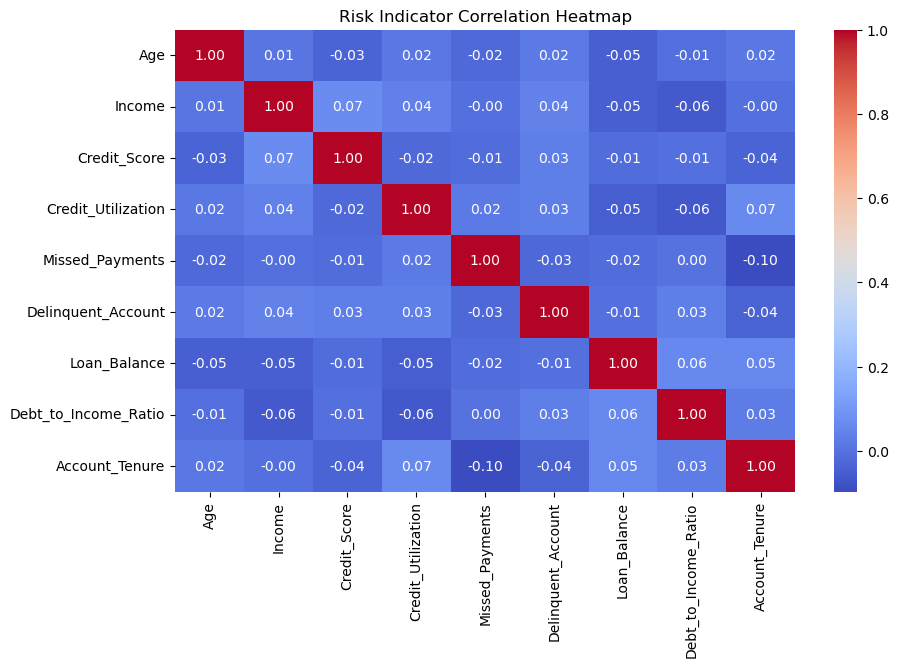

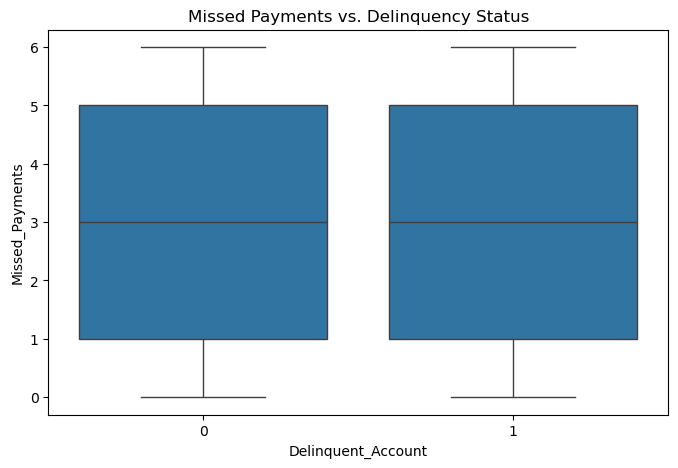

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a Correlation Heatmap
plt.figure(figsize=(10, 6))
# We select only numeric columns for the heatmap
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Risk Indicator Correlation Heatmap')
plt.show()

# 2. Create a Boxplot for Missed Payments
plt.figure(figsize=(8, 5))
sns.boxplot(x='Delinquent_Account', y='Missed_Payments', data=df)
plt.title('Missed Payments vs. Delinquency Status')
plt.show()